In [68]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OrdinalEncoder
sns.set_style("whitegrid")

In [69]:
df =pd.read_csv('youtube_videos.csv')

In [70]:
df.head()

,video_id,title,category,channel_tier,upload_day,upload_hour,duration_seconds,views,likes,comments,shares,watch_time_minutes,avg_view_duration_seconds,click_through_rate,channel_age_years,subscribers,tags_count,hashtags
0,vid_0000,I tried EVERY transformers tool — the WINNER s...,Music,Mid,Sunday,0,721,228102,9979,2810,1193,1091087,287,0.0100,1.3,441016,18.0,"[""ai"", ""tutorial"", ""trending""]"
1,vid_0001,What nobody tells you about AI image tools,Gaming,Small,Saturday,21,1894,25078,962,283,183,423818,1014,0.0230,0.8,25339,17.0,"[""tutorial""]"
2,vid_0002,What nobody tells you about machine learning p...,Gaming,Large,Monday,18,1413,1323949,6619,25177,16119,12952634,587,0.1022,4.8,2398429,NaN,"[""explained""]"
3,vid_0003,Is Claude worth it in 2025?,Gaming,Mid,Thursday,14,1335,187752,4936,2051,1797,2018334,645,0.0413,3.9,498144,13.0,"[""gaming"", ""trending"", ""explained"", ""tech""]"
4,vid_0004,URGENT: voice cloning AI is about to CHANGE FO...,Music,Small,Monday,4,3158,12583,777,98,30,262565,1252,0.0100,1.3,30039,10.0,"[""explained"", ""shorts""]"


In [71]:
df["watch_time_minutes"]

0       1091087
1        423818
2      12952634
3       2018334
4        262565
         ...   
205       87597
206      132347
207     2266550
208       97538
209      843678
Name: watch_time_minutes, Length: 210, dtype: int64

In [72]:
scaler = MinMaxScaler()

In [73]:
df["subscribers_minmax"] = scaler.fit_transform(df[["watch_time_minutes"]])

In [74]:
df["watch_time_minutes"].describe()

count    2.100000e+02
mean     1.461476e+07
std      6.595676e+07
min      2.494000e+03
25%      1.399760e+05
50%      6.607500e+05
75%      3.844212e+06
max      7.376597e+08
Name: watch_time_minutes, dtype: float64

In [75]:
standard_scaler = StandardScaler()

In [76]:
df["likes_zscore"] = standard_scaler.fit_transform(df[["likes"]])

In [77]:
df[["likes", "likes_zscore"]].describe()

,likes,likes_zscore
count,210.000000,2.100000e+02
mean,25765.304762,8.458842e-18
std,66234.880530,1.002389e+00
min,33.000000,-3.894291e-01
25%,488.750000,-3.825319e-01
50%,2204.000000,-3.565735e-01
75%,12510.750000,-2.005926e-01
max,455256.000000,6.499853e+00


In [78]:
df["watch_time_minutes_log"] = np.log1p(df["watch_time_minutes"])

In [79]:
df["watch_time_minutes_log"].describe

<bound method NDFrame.describe of 0      13.902686
1      12.957062
2      16.376810
3      14.517783
4      12.478258
         ...    
205    11.380513
206    11.793190
207    14.633770
208    11.488008
209    13.645527
Name: watch_time_minutes_log, Length: 210, dtype: float64>

<Axes: xlabel='watch_time_minutes', ylabel='Count'>

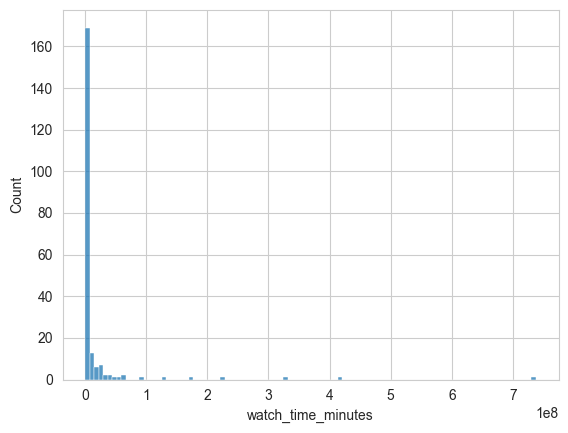

In [80]:
sns.histplot(df["watch_time_minutes"], bins=100)

In [81]:
bins = [0, 300, 2000, float("inf")]
labels = ["short", "medium", "long"]
df["duration_bins"] = pd.cut(df["duration_seconds"], bins=bins, labels=labels)


<Axes: xlabel='duration_bins', ylabel='count'>

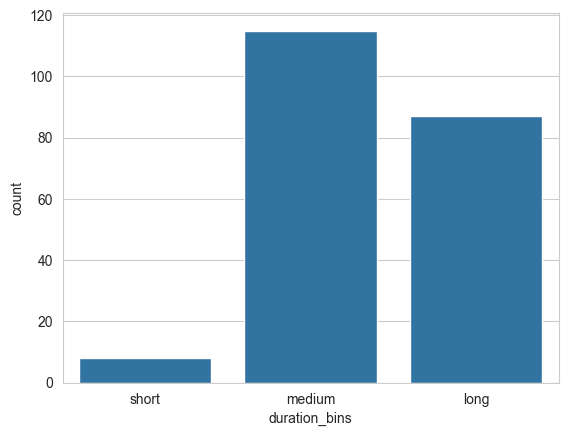

In [82]:
sns.countplot(x="duration_bins", data=df)

In [83]:
bins = [0, 100, 1000, float("inf")]
labels = ["little", "some", "a lot"]
df["likes_bins"] = pd.cut(df["likes"], bins=bins, labels=labels)


<Axes: xlabel='likes_bins', ylabel='count'>

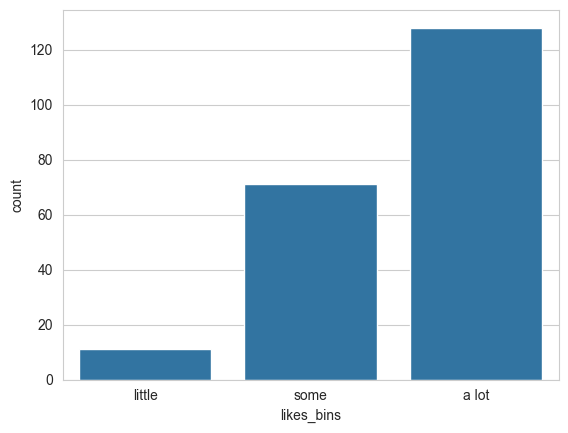

In [84]:
sns.countplot(x="likes_bins", data=df)

In [91]:
df["channel_tier"].unique()

array(['Mid', 'Small', 'Large'], dtype=object)

In [93]:
encoder = OrdinalEncoder(categories=[['Small', 'Mid', 'Large']])
df["channel_tier_encoded"] = encoder.fit_transform(df[["channel_tier"]]).astype(int)

In [95]:
df["channel_tier"]

0        Mid
1      Small
2      Large
3        Mid
4      Small
       ...  
205    Small
206    Small
207      Mid
208    Small
209      Mid
Name: channel_tier, Length: 210, dtype: object

In [97]:
dummyVars = pd.get_dummies(df["category"], prefix="is")

In [99]:
dummyVars.head(10)

,is_Comedy,is_Education,is_Gaming,is_Music,is_News,is_Vlog
0,False,False,False,True,False,False
1,False,False,True,False,False,False
2,False,False,True,False,False,False
3,False,False,True,False,False,False
4,False,False,False,True,False,False
5,False,False,False,False,True,False
6,False,True,False,False,False,False
7,False,False,False,False,True,False
8,False,False,True,False,False,False
9,False,False,False,False,True,False


In [101]:
df=pd.concat([df, dummyVars], axis=1)
df

,video_id,title,category,channel_tier,upload_day,upload_hour,duration_seconds,views,likes,comments,...,is_Gaming,is_Music,is_News,is_Vlog,is_Comedy,is_Education,is_Gaming,is_Music,is_News,is_Vlog
0,vid_0000,I tried EVERY transformers tool — the WINNER s...,Music,Mid,Sunday,0,721,228102,9979,2810,...,False,True,False,False,False,False,False,True,False,False
1,vid_0001,What nobody tells you about AI image tools,Gaming,Small,Saturday,21,1894,25078,962,283,...,True,False,False,False,False,False,True,False,False,False
2,vid_0002,What nobody tells you about machine learning p...,Gaming,Large,Monday,18,1413,1323949,6619,25177,...,True,False,False,False,False,False,True,False,False,False
3,vid_0003,Is Claude worth it in 2025?,Gaming,Mid,Thursday,14,1335,187752,4936,2051,...,True,False,False,False,False,False,True,False,False,False
4,vid_0004,URGENT: voice cloning AI is about to CHANGE FO...,Music,Small,Monday,4,3158,12583,777,98,...,False,True,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,vid_0205,STOP using Python for AI WRONG (most people do...,Education,Small,Friday,13,1737,6441,147,52,...,False,False,False,False,False,True,False,False,False,False
206,vid_0206,I built a machine learning pipelines project —...,News,Small,Saturday,8,5776,4755,249,63,...,False,False,True,False,False,False,False,False,True,False
207,vid_0207,What nobody tells you about Gemini,Gaming,Mid,Sunday,20,2617,104852,921,1069,...,True,False,False,False,False,False,True,False,False,False
208,vid_0208,Why deep learning frameworks DESTROYED my work...,Comedy,Small,Thursday,21,3656,3026,165,48,...,False,False,False,False,True,False,False,False,False,False


In [102]:
day_map = {
    "Monday": 0, "Tuesday": 1, "Wednesday": 2,
    "Thursday": 3, "Friday": 4, "Saturday": 5, "Sunday": 6
}
rng = np.random.default_rng(42)
base = pd.Timestamp("2024-01-01")

df["uploaded_at"] = [
    base
    + pd.offsets.Week(weekday=day_map[d])
    + pd.Timedelta(hours=int(h))
    + pd.Timedelta(minutes=int(rng.integers(0, 60)))
    for d, h in zip(df["upload_day"], df["upload_hour"])
]

In [104]:
df["uploaded_at"]

0     2024-01-07 00:05:00
1     2024-01-06 21:46:00
2     2024-01-08 18:39:00
3     2024-01-04 14:26:00
4     2024-01-08 04:25:00
              ...        
205   2024-01-05 13:15:00
206   2024-01-06 08:45:00
207   2024-01-07 20:58:00
208   2024-01-04 21:15:00
209   2024-01-05 10:46:00
Name: uploaded_at, Length: 210, dtype: datetime64[ns]

In [105]:
df["uploaded_at"].dt.dayofweek

0      6
1      5
2      0
3      3
4      0
      ..
205    4
206    5
207    6
208    3
209    4
Name: uploaded_at, Length: 210, dtype: int32

In [106]:
df["caps_count"] = df["title"].apply(
    lambda x: sum(1 for c in x if c.isupper())
)

In [107]:
df["caps_count"]

0      12
1       3
2       1
3       2
4      21
       ..
205    12
206     2
207     2
208    11
209    10
Name: caps_count, Length: 210, dtype: int64

In [112]:
df["duration_minutes"] = df["duration_seconds"] / 60
df["retention_rate"] = df["watch_time_minutes"] / df["duration_minutes"]

In [113]:
df["retention_rate"]

0       90797.808599
1       13426.124604
2      550005.690021
3       90711.640449
4        4988.568714
           ...      
205      3025.803109
206      1374.795706
207     51965.227360
208      1600.733042
209     63039.452055
Name: retention_rate, Length: 210, dtype: float64